---

## 9. Scatterplot — Relationships Between Numbers

**What it does:** Same as Matplotlib scatter, but Seaborn can **color dots by category** automatically.  
**When to use:** When you want to check if two numeric columns are **related**, and optionally see how a category affects the pattern.  
**Business question:** *"Is there a relationship between Price and Revenue? Does it differ by category?"*

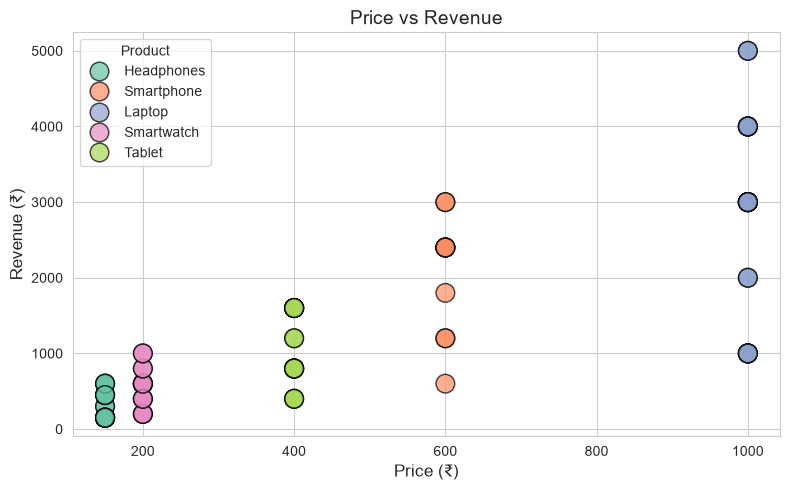

In [16]:
# ============================================
# SCATTERPLOT: Price vs Revenue
# ============================================

plt.figure(figsize=(8, 5))

# Basic scatter plot
sns.scatterplot(x='Price', y='Revenue', data=df, s=180, alpha=0.7, edgecolor='black',hue="Product")

plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Price vs Revenue', fontsize=14)

plt.tight_layout()
plt.show()

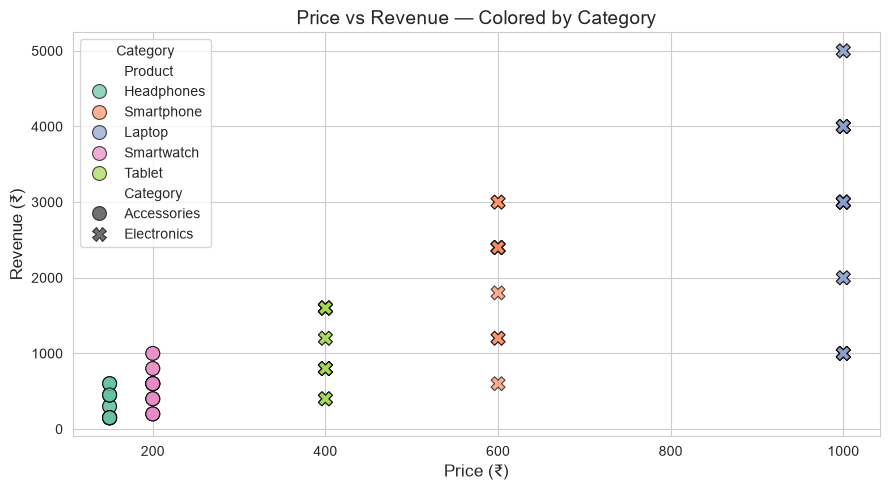

In [18]:
# ============================================
# SCATTERPLOT #2: Price vs Revenue, colored by Category
# ============================================

plt.figure(figsize=(9, 5))

# 'hue' automatically colors dots by category and adds a legend!
sns.scatterplot(x='Price', y='Revenue', data=df,
                hue='Product',          # Color by category
                style='Category',         # Different marker shapes per category
                s=100, alpha=0.7, edgecolor='black')

plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Price vs Revenue — Colored by Category', fontsize=14)
plt.legend(title='Category', fontsize=10)

plt.tight_layout()
plt.show()

### 📝 How to Read This Chart

- Each dot is a transaction, colored by category.
- You can now see **which category** occupies which part of the Price-Revenue space.
- Electronics (higher prices) cluster in the **upper-right** area.
- Accessories (lower prices) cluster in the **lower-left** area.

### 💡 Sample Business Insight

> *"There is a clear positive relationship between Price and Revenue. Electronics transactions dominate the high-price, high-revenue segment. Accessories are clustered in the low-price area, with revenue growth mainly driven by quantity."*

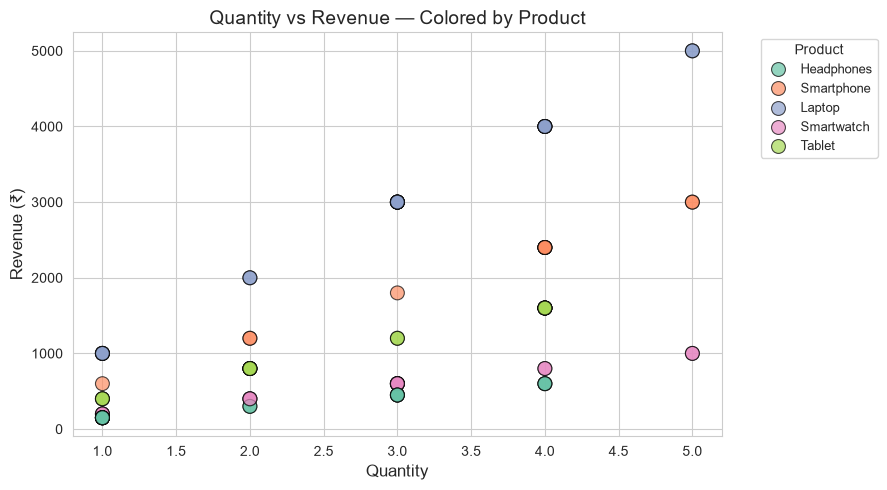

In [ ]:
# ============================================
# SCATTERPLOT #3: Quantity vs Revenue, colored by Product
# ============================================

plt.figure(figsize=(9, 5))

sns.scatterplot(x='Quantity', y='Revenue', data=df,
                hue='Product', s=100, alpha=0.7, edgecolor='black')

plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Quantity vs Revenue — Colored by Product', fontsize=14)
plt.legend(title='Product', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

---

## 10. Correlation Heatmap — The Most Powerful EDA Chart 🔥

**What it does:** Shows how strongly numeric columns are **related** to each other using colors.  
**When to use:** When you want a quick overview of all numeric relationships in your data.  
**Business question:** *"Which variables are most correlated with Revenue?"*

### What is Correlation?

Correlation is a number between **-1 and +1** that tells you how two variables move together:

| Value | Meaning | Example |
|---|---|---|
| **+1** | Perfect positive — both go up together | Price ↑ → Revenue ↑ |
| **0** | No relationship | Day of month → Revenue |
| **-1** | Perfect negative — one goes up, other goes down | Discount ↑ → Price ↓ |



In [20]:
# ============================================
# Step 1: Calculate the correlation matrix
# ============================================

# Select only numeric columns for correlation
numeric_cols = ['Price', 'Quantity', 'Revenue', 'Day', 'Revenue_Per_Unit']

# .corr() calculates correlation between every pair of numeric columns
correlation_matrix = df[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))  # Round to 2 decimal places

Correlation Matrix:
                  Price  Quantity  Revenue   Day  Revenue_Per_Unit
Price              1.00      0.18     0.80 -0.05              1.00
Quantity           0.18      1.00     0.63  0.22              0.18
Revenue            0.80      0.63     1.00  0.08              0.80
Day               -0.05      0.22     0.08  1.00             -0.05
Revenue_Per_Unit   1.00      0.18     0.80 -0.05              1.00


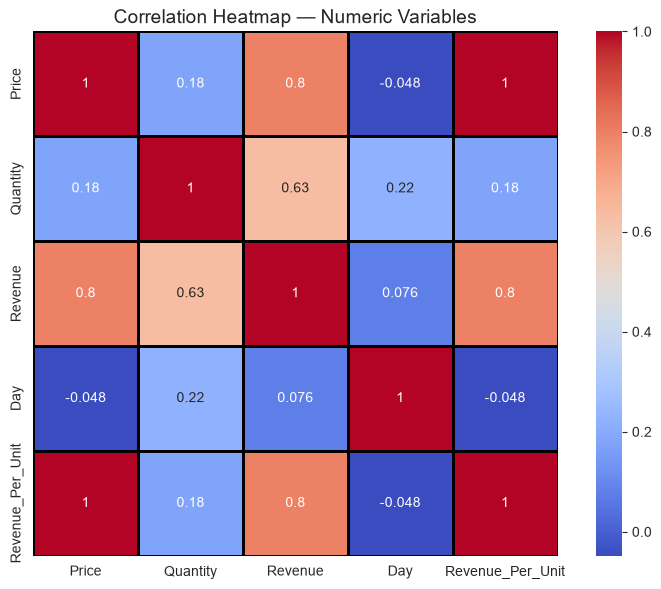

In [21]:
# ============================================
# HEATMAP: Visualize the correlation matrix
# ============================================

plt.figure(figsize=(8, 6))

# sns.heatmap turns the correlation matrix into a colored grid
sns.heatmap(correlation_matrix,
            annot=True,          # Show numbers on the heatmap
            cmap='coolwarm',     # Color scheme: blue = negative, red = positive
            linewidths=1,        # Add grid lines between cells
            linecolor='black',   # Grid line color
            square=True          # Make cells square-shaped
           )     

plt.title('Correlation Heatmap — Numeric Variables', fontsize=14)

plt.tight_layout()
plt.show()

### 📝 How to Read This Heatmap

- Each cell shows the correlation between two variables.
- **Dark red/warm colors** = strong positive correlation (both go up together).
- **Dark blue/cool colors** = strong negative correlation (one goes up, other goes down).
- **White/light colors** = weak or no correlation.
- The **diagonal** is always 1.00 (a variable is perfectly correlated with itself).

### 💡 Sample Business Insight

> *"Price and Revenue have a strong positive correlation — higher-priced products tend to generate higher revenue. Price and Revenue_Per_Unit show perfect correlation (1.00), which makes sense since Revenue_Per_Unit equals Price. Quantity has a moderate positive correlation with Revenue, confirming that selling more units increases revenue. Day of month has almost no correlation with any variable, meaning sales don't follow a strong daily pattern within the month."*

---

## 11. How to Write Business Insights from Charts

Now that you know how to create charts, the **most important skill** is being able to explain what they mean.

### The 4-Step Insight Framework:

| Step | Question | Example |
|---|---|---|
| 1. **What** is the chart showing? | Describe in plain language | "This boxplot compares revenue across products." |
| 2. **What pattern** do we observe? | State the finding | "Laptop has the highest median revenue but also the widest spread." |
| 3. **Why** does it matter? | Explain the significance | "High variation means some Laptop transactions are much more valuable." |
| 4. **What action** can we take? | Suggest a business decision | "The business should investigate what drives high-value Laptop purchases and replicate those conditions." |

### ❌ Weak insight:
> *"The boxplot shows data."*

### ✅ Strong insight:
> *"Laptop has the highest median revenue (₹X) but also shows the most variation. This suggests that bulk Laptop purchases occasionally drive very high revenue. The business should consider creating bulk-purchase discount programs to incentivize more high-value Laptop transactions."*

---

## 12. Mini EDA Storytelling Section 📖

Let's combine everything we've learned into a **mini data story**. This is what you'd present in a team meeting or a project report.

### The Story of Our Retail Sales Data

We'll answer 4 key business questions with charts and insights.

### Story Question 1: "What products do we sell the most?" 🛒

C:\Users\pbawa\AppData\Local\Temp\ipykernel_24620\3878498609.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Product', data=df, order=df['Product'].value_counts().index,
C:\Users\pbawa\AppData\Local\Temp\ipykernel_24620\3878498609.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pbawa\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


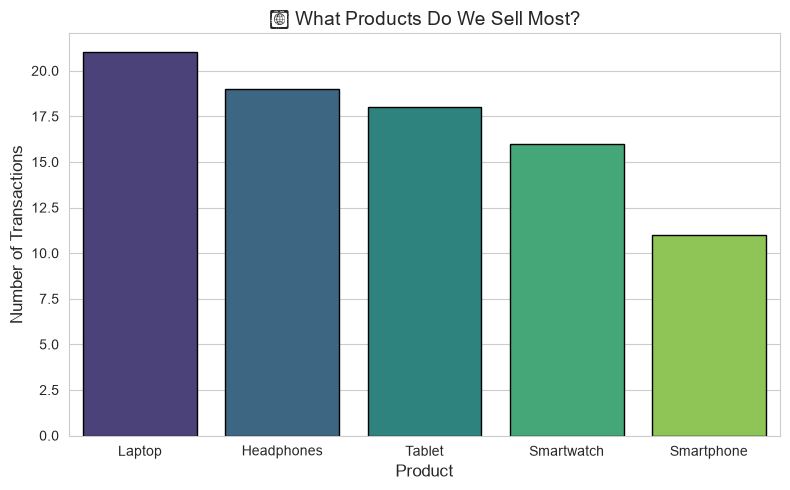

📝 Insight:
Laptop and Headphones are the most frequently sold products.
However, frequency alone doesn't tell us about profitability — we need to look at revenue next.


In [ ]:
# ============================================
# STORY CHART 1: Transaction count by Product
# ============================================

plt.figure(figsize=(8, 5))

sns.countplot(x='Product', data=df, order=df['Product'].value_counts().index,
              palette='viridis', edgecolor='black')

plt.xlabel('Product', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('📊 What Products Do We Sell Most?', fontsize=14)

plt.tight_layout()
plt.show()

# ---- INSIGHT ----
print("📝 Insight:")
print("Laptop and Headphones are the most frequently sold products.")
print("However, frequency alone doesn't tell us about profitability — we need to look at revenue next.")

### Story Question 2: "Which product generates the most revenue?" 💰

C:\Users\pbawa\AppData\Local\Temp\ipykernel_24620\1025049290.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product', y='Revenue', data=df, order=product_order,
C:\Users\pbawa\AppData\Local\Temp\ipykernel_24620\1025049290.py:16: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pbawa\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


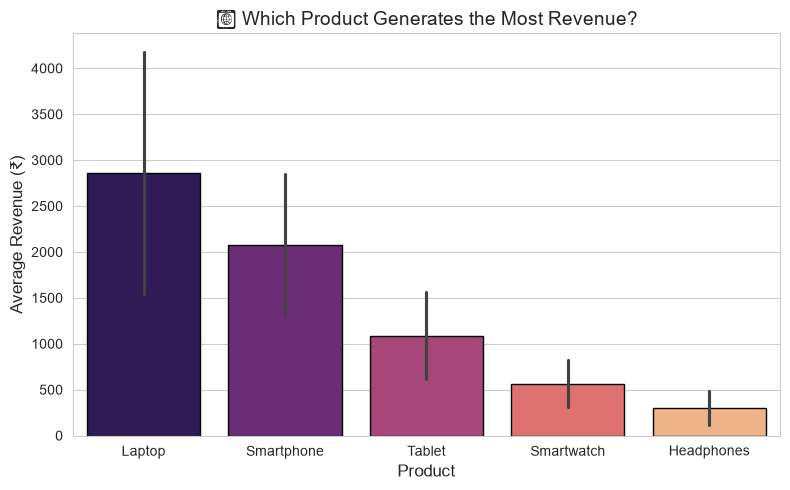

📝 Insight:
Laptop leads in average revenue per transaction despite not having the most transactions.
This is because Laptop has the highest price point.
Business Recommendation: Prioritize Laptop marketing and ensure adequate stock.


In [ ]:
# ============================================
# STORY CHART 2: Average revenue by Product
# ============================================

plt.figure(figsize=(8, 5))

product_order = df.groupby('Product')['Revenue'].mean().sort_values(ascending=False).index

sns.barplot(x='Product', y='Revenue', data=df, order=product_order,
            palette='magma', edgecolor='black', errorbar='sd')

plt.xlabel('Product', fontsize=12)
plt.ylabel('Average Revenue (₹)', fontsize=12)
plt.title('💰 Which Product Generates the Most Revenue?', fontsize=14)

plt.tight_layout()
plt.show()

# ---- INSIGHT ----
print("📝 Insight:")
print("Laptop leads in average revenue per transaction despite not having the most transactions.")
print("This is because Laptop has the highest price point.")
print("Business Recommendation: Prioritize Laptop marketing and ensure adequate stock.")

### Story Question 3: "How is revenue distributed? Are there outliers?" 📦

C:\Users\pbawa\AppData\Local\Temp\ipykernel_24620\2749055992.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Revenue', data=df, palette='pastel', ax=axes[1],


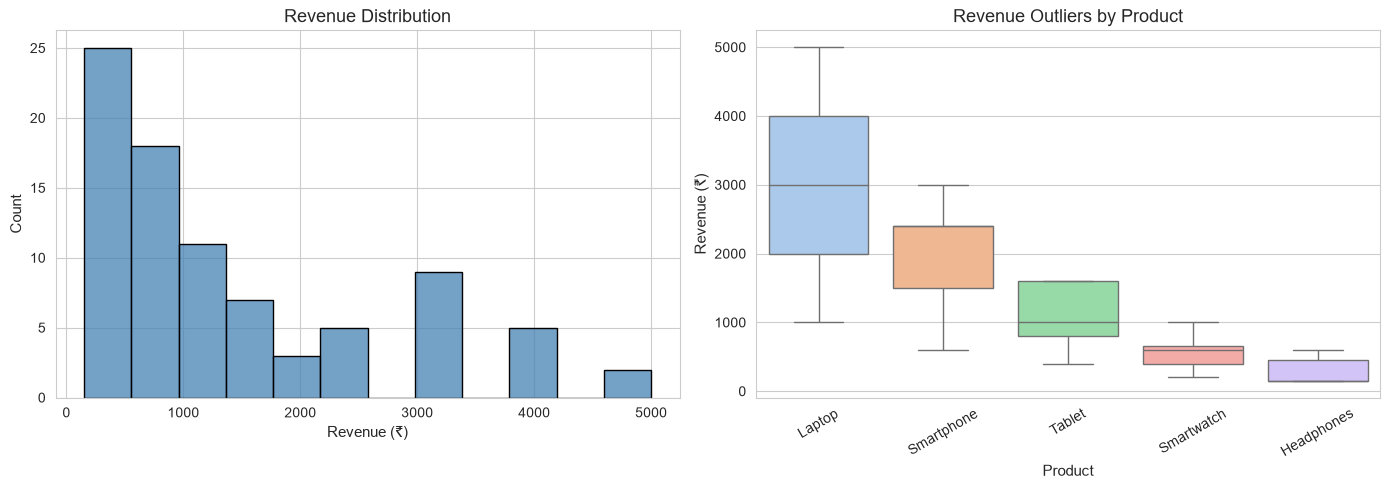

📝 Insight:
Revenue is right-skewed — most transactions are below ₹2000.
Laptop has the widest revenue range, suggesting variable purchase quantities.
Pattern: High-value outlier transactions are mostly from Laptop and Smartphone.


In [ ]:
# ============================================
# STORY CHART 3: Revenue distribution + boxplot
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram
sns.histplot(data=df, x='Revenue', bins=12, color='steelblue',
             edgecolor='black', ax=axes[0])
axes[0].set_title('Revenue Distribution', fontsize=13)
axes[0].set_xlabel('Revenue (₹)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

# Right: Boxplot by Product
sns.boxplot(x='Product', y='Revenue', data=df, palette='pastel', ax=axes[1],
            order=['Laptop', 'Smartphone', 'Tablet', 'Smartwatch', 'Headphones'])
axes[1].set_title('Revenue Outliers by Product', fontsize=13)
axes[1].set_xlabel('Product', fontsize=11)
axes[1].set_ylabel('Revenue (₹)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ---- INSIGHT ----
print("📝 Insight:")
print("Revenue is right-skewed — most transactions are below ₹2000.")
print("Laptop has the widest revenue range, suggesting variable purchase quantities.")
print("Pattern: High-value outlier transactions are mostly from Laptop and Smartphone.")

### Story Question 4: "What drives revenue? Which factors are correlated?" 🔥

C:\Users\pbawa\AppData\Local\Temp\ipykernel_24620\4156219739.py:16: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pbawa\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


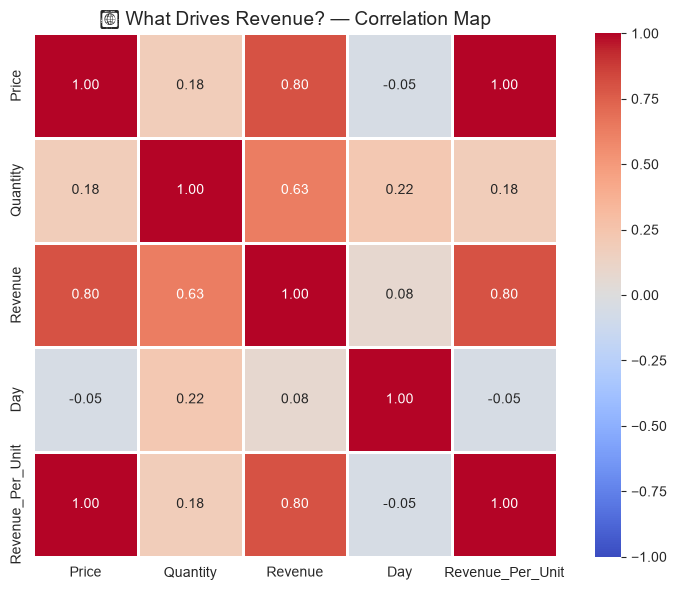

📝 Insight:
Both Price and Quantity are positively correlated with Revenue.
Price has a stronger correlation with Revenue than Quantity does.
This means the PRICE of the product matters more for revenue than the quantity sold.
Business Recommendation: To increase revenue, focus on promoting higher-priced products
rather than just increasing the quantity of low-priced items.


In [ ]:
# ============================================
# STORY CHART 4: Correlation heatmap
# ============================================

plt.figure(figsize=(8, 6))

numeric_cols = ['Price', 'Quantity', 'Revenue', 'Day', 'Revenue_Per_Unit']
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=1, linecolor='white',
            square=True, vmin=-1, vmax=1)

plt.title('🔥 What Drives Revenue? — Correlation Map', fontsize=14)

plt.tight_layout()
plt.show()

# ---- INSIGHT ----
print("📝 Insight:")
print("Both Price and Quantity are positively correlated with Revenue.")
print("Price has a stronger correlation with Revenue than Quantity does.")
print("This means the PRICE of the product matters more for revenue than the quantity sold.")
print("Business Recommendation: To increase revenue, focus on promoting higher-priced products")
print("rather than just increasing the quantity of low-priced items.")

---

## 13. Data Storytelling Template

When presenting your EDA findings, follow this structure:

```
📊 CHART: [Show the chart]

❓ WHAT is the chart showing?
   → This [chart type] shows [variable] across [categories/time].

🔍 WHAT PATTERN do we observe?
   → We can see that [key finding].

💡 WHY does it matter?
   → This is important because [business context].

🎯 WHAT BUSINESS DECISION can be made?
   → Based on this, the business should [recommendation].
```

### Pro Tips for Presentations:
- **One chart per slide** — don't overcrowd
- **Title should tell the story** — "Revenue Peaks on Weekends" is better than "Revenue Chart"
- **Highlight the key number** — use annotations or print the exact value
- **Keep it simple** — your audience may not know what a boxplot is!

---

## 14. Quick Reference — Seaborn Chart Selection

| Question | Chart | Seaborn Function |
|---|---|---|
| How many of each category? | Countplot | `sns.countplot()` |
| What is the average by category? | Barplot | `sns.barplot()` |
| How is the data spread? | Histplot | `sns.histplot()` |
| Are there outliers by group? | Boxplot | `sns.boxplot()` |
| Is there a relationship? | Scatterplot | `sns.scatterplot()` |
| Which variables are correlated? | Heatmap | `sns.heatmap()` |

**Seaborn extras that make life easier:**
- `hue` — color by category
- `palette` — change color scheme
- `order` — sort categories
- `edgecolor` — add borders to bars/dots

---

## 📝 Practice Questions

Try these on your own using the Retail Sales dataset:

1. **Countplot:** Create a countplot showing how many transactions are "High Value" vs "Not High Value" (use the `Is_High_Value` column).

2. **Barplot:** Create a barplot showing the **average Quantity** sold per product. Which product has the highest average quantity?

3. **Histplot:** Plot the distribution of `Price` with `hue='Category'`. Use `multiple='dodge'` to place bars side by side.

4. **Boxplot:** Create a boxplot of `Quantity` grouped by `Product`. Are there any quantity outliers?

5. **Scatterplot:** Create a scatter plot of `Quantity` vs `Revenue`, colored by `Product`. Write a 2-line insight.

6. **Heatmap:** Create a correlation heatmap using only `Price`, `Quantity`, and `Revenue`. Which pair has the strongest correlation?

7. **Insight Writing:** Pick any 2 charts from the practice questions above and write a full 4-step insight (What → Pattern → Why → Action).

8. **(Optional — Bonus):** Look up `sns.violinplot()` in the Seaborn documentation and create a violin plot of Revenue by Category. How is it different from a boxplot?

C:\Users\HP\AppData\Local\Temp\ipykernel_39244\1749773165.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = "Is_High_Value", order = df['Is_High_Value'].value_counts().index, palette='pastel', edgecolor = 'black')


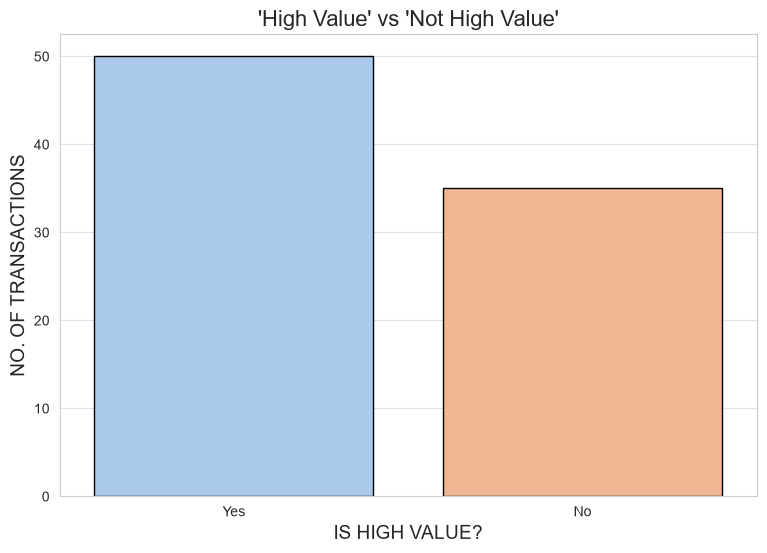

In [29]:
# ============================================
# YOUR PRACTICE SPACE — Question 1
# ============================================

# 1. **Countplot:** Create a countplot showing how many transactions are "High Value" vs "Not High Value" (use the `Is_High_Value` column).
plt.figure(figsize=(9,6))

sns.countplot(data = df, x = "Is_High_Value", order = df['Is_High_Value'].value_counts().index, palette='pastel', edgecolor = 'black')

plt.title(f"'High Value' vs 'Not High Value'", fontsize = 16)
plt.xlabel("IS HIGH VALUE?", fontsize = 14)
plt.ylabel("NO. OF TRANSACTIONS", fontsize = 14)
plt.grid(axis='y', alpha = 0.6)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_39244\681534530.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x = "Product", y = "Quantity", order = average, palette='pastel', edgecolor = 'black')


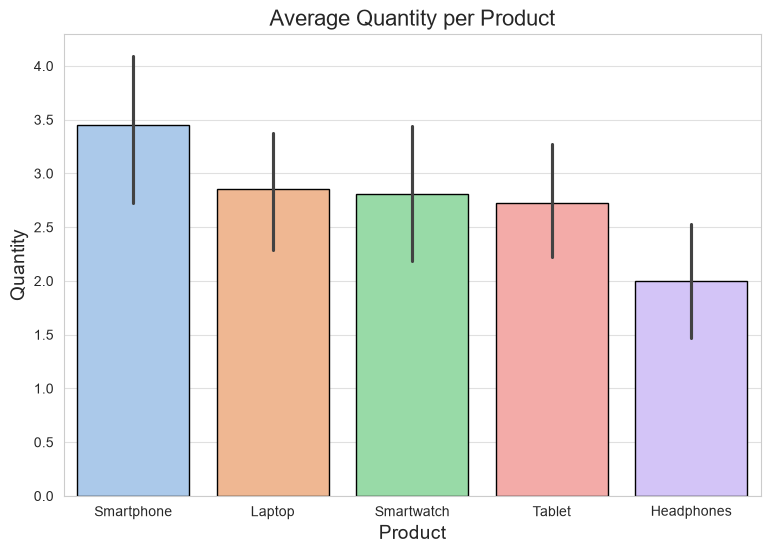

In [42]:
# ============================================
# YOUR PRACTICE SPACE — Question 2
# ============================================
# 2. **Barplot:** Create a barplot showing the **average Quantity** sold per product. Which product has the highest average quantity?
average = df.groupby('Product')['Quantity'].mean().sort_values(ascending=False).index
plt.figure(figsize=(9,6))

sns.barplot(data = df, x = "Product", y = "Quantity", order = average, palette='pastel', edgecolor = 'black')

plt.title(f"Average Quantity per Product", fontsize = 16)
plt.xlabel("Product", fontsize = 14)
plt.ylabel("Quantity", fontsize = 14)
plt.grid(axis='y', alpha = 0.6)
plt.show()


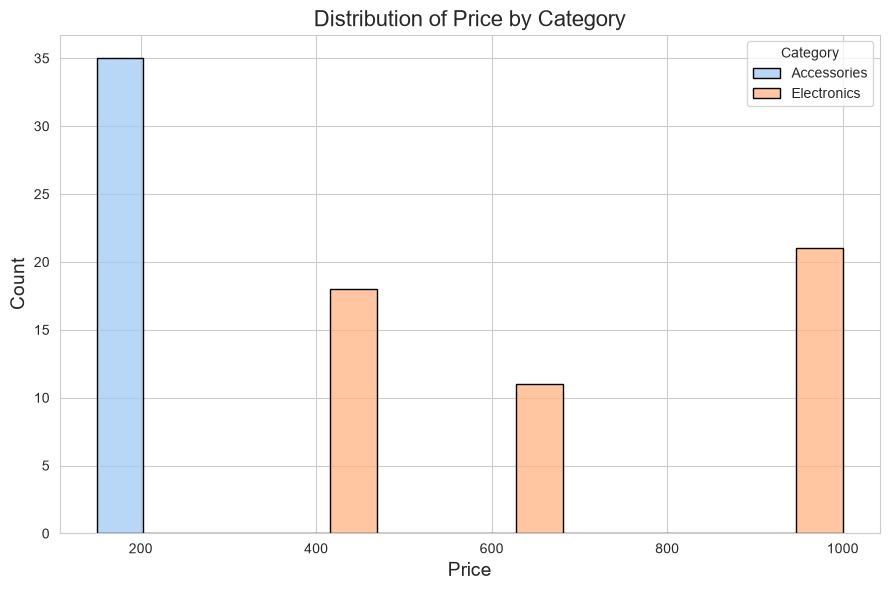

In [51]:
# ============================================
# YOUR PRACTICE SPACE — Question 3
# ============================================
# 3. **Histplot:** Plot the distribution of `Price` with `hue='Category'`. Use `multiple='dodge'` to place bars side by side.
plt.figure(figsize=(9,6))

sns.histplot(data = df, x = "Price", hue='Category',  multiple='dodge', palette='pastel', edgecolor = 'black')

plt.title(f"Distribution of Price by Category", fontsize = 16)
plt.xlabel("Price", fontsize = 14)
plt.ylabel("Count", fontsize = 14)
plt.tight_layout()
plt.show()



C:\Users\HP\AppData\Local\Temp\ipykernel_39244\35944758.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Product", y = "Quantity", palette='pastel')


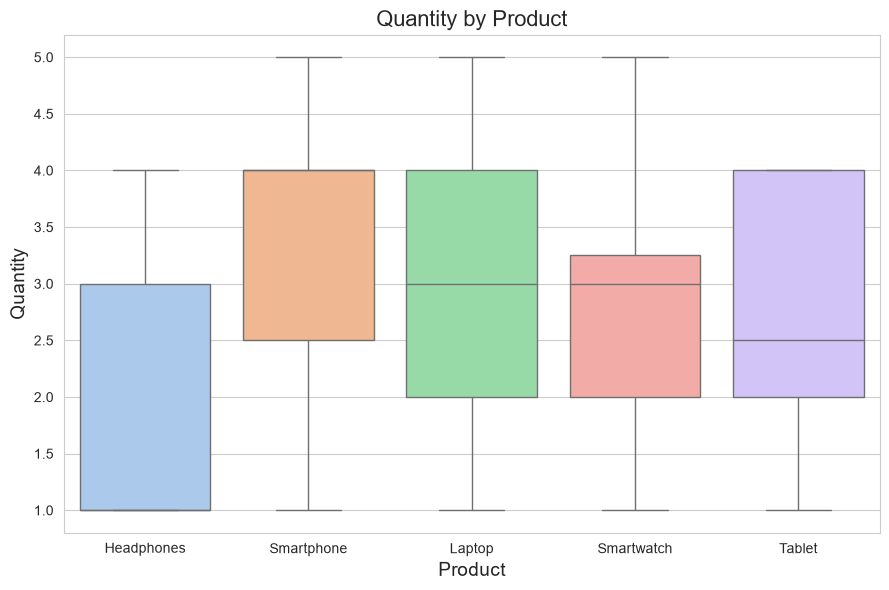

In [ ]:
# ============================================
# YOUR PRACTICE SPACE — Question 4
# ============================================

plt.figure(figsize=(9,6))

sns.boxplot(data = df, x = "Product", y = "Quantity", palette='pastel')

plt.title(f"Quantity by Product", fontsize = 16)
plt.xlabel("Product", fontsize = 14)
plt.ylabel("Quantity", fontsize = 14)
plt.tight_layout()
plt.show()


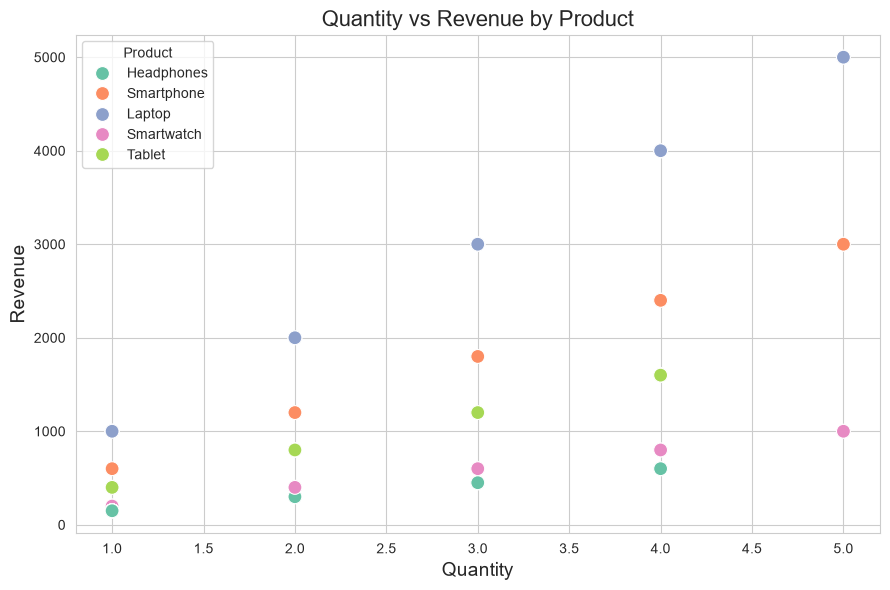

In [ ]:
# ============================================
# YOUR PRACTICE SPACE — Question 5
# ============================================
# **Scatterplot:** Create a scatter plot of `Quantity` vs `Revenue`, colored by `Product`. Write a 2-line insight.

plt.figure(figsize=(9,6))

sns.scatterplot(data = df, x = "Quantity", y = "Revenue", hue='Product', palette='Set2', s = 100)

plt.title("Quantity vs Revenue by Product", fontsize=16)
plt.xlabel("Quantity", fontsize=14)
plt.ylabel("Revenue", fontsize=14)

plt.tight_layout()
plt.show()



Correlation Matrix:
          Price  Quantity  Revenue
Price      1.00      0.18     0.80
Quantity   0.18      1.00     0.63
Revenue    0.80      0.63     1.00


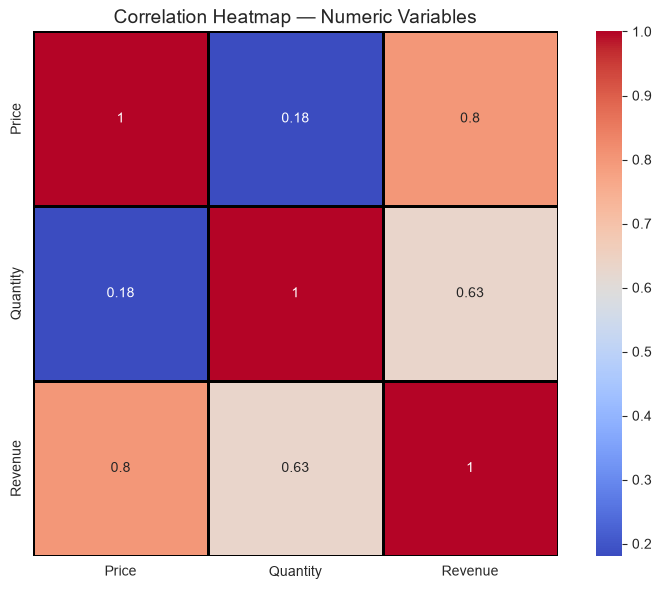

In [ ]:
# ============================================
# YOUR PRACTICE SPACE — Question 6
# ============================================

# 6. **Heatmap:** Create a correlation heatmap using only `Price`, `Quantity`, and `Revenue`. Which pair has the strongest correlation?
numeric_cols = ['Price', 'Quantity', 'Revenue']

correlation_matrix = df[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))  

plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix,
            annot=True,          # Show numbers on the heatmap
            cmap='coolwarm',     # Color scheme: blue = negative, red = positive
            linewidths=1,        # Add grid lines between cells
            linecolor='black',   # Grid line color
            square=True          # Make cells square-shaped
           )     

plt.title('Correlation Heatmap — Numeric Variables', fontsize=14)

plt.tight_layout()
plt.show()

# 8. **(Optional — Bonus):** Look up `sns.violinplot()` in the Seaborn documentation and create a violin plot of Revenue by Category. How is it different from a boxplot?


In [3]:
# 7. **Insight Writing:** Pick any 2 charts from the practice questions above and write a full 4-step insight (What → Pattern → Why → Action).

print("Insight for scatterplot")
print("\nLaptops generate the highest revenue across all quantity levels, indicating they are the company's most valuable product. Maintaining adequate laptop inventory can help ensure consistent revenue generation.")

print("\nInsight for High value VS Not High Value")
print("\nHigh-value transactions outnumber non-high-value transactions, with approximately 50 high-value transactions compared to 35 non-high-value transactions. This indicates that a larger share of sales comes from high-value purchases, suggesting the business is effectively generating revenue from premium transactions.")

Insight for scatterplot

Laptops generate the highest revenue across all quantity levels, indicating they are the company's most valuable product. Maintaining adequate laptop inventory can help ensure consistent revenue generation.

Insight for High value VS Not High Value

High-value transactions outnumber non-high-value transactions, with approximately 50 high-value transactions compared to 35 non-high-value transactions. This indicates that a larger share of sales comes from high-value purchases, suggesting the business is effectively generating revenue from premium transactions.


---

## 🎯 Assignment: EDA Storytelling Report

**Objective:** Create a mini EDA storytelling report using the Retail Sales dataset.

**Instructions:**

1. Answer **each of the following 5 business questions** with one Seaborn chart:

   | # | Business Question | Suggested Chart |
   |---|---|---|
   | 1 | How many transactions does each product have? | `countplot` |
   | 2 | What is the average revenue for each category? | `barplot` |
   | 3 | How is revenue distributed across transactions? | `histplot` |
   | 4 | Are there revenue outliers for any product? | `boxplot` |
   | 5 | What factors are most correlated with Revenue? | `heatmap` |

2. For **each chart**, write a **4-step insight** using the framework:
   - **What** is the chart showing?
   - **What pattern** do we observe?
   - **Why** does it matter?
   - **What business decision** can be made?

3. At the end, write a **3–5 sentence executive summary** combining your key findings.

**Submission:** Complete the assignment in the cells below or in a new notebook.

---

## ✅ Summary

In this notebook, we learned:

| Topic | What We Covered |
|---|---|
| **Seaborn** | A library built on Matplotlib with better defaults |
| **countplot** | Count occurrences of categories |
| **barplot** | Compare averages across categories |
| **histplot** | Visualize data distribution |
| **boxplot** | Compare distributions & detect outliers |
| **scatterplot** | Explore relationships between numbers |
| **heatmap** | Visualize correlations between all numeric variables |
| **hue** | Color data points/bars by category |
| **Data Storytelling** | What → Pattern → Why → Action |

### 🏆 What you can now do:
- Choose the correct chart for any data question
- Create clean, readable charts with Seaborn
- Detect trends, distributions, outliers, and correlations
- Write meaningful business insights from every chart
- Tell a data story that combines charts and insights

**Great job! You're now ready for more advanced EDA and machine learning preparation!** 🚀